In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Importar módulo de regressão linear da biblioteca scikit learn
from sklearn.linear_model import LinearRegression

# Superfície de erro
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


**Funções Objetivo, Observável e Predita.**

In [2]:
# função recebe 6 parâmetros.
# x1 e x2 -> Variaveis independentes (entradas do modelo)
# y valores reais da função objetivo.
# y_noise valores da função objetivo com ruído
# y_pred_plano: Não está sendo usado no código, pode ser um resquício de versões anteriores.
# a_numpy_plano, array contendo os coeficientes das função hipótese.

def plot_objetivo_observavel_pred_3D (x1, x2, y, y_noisy, y_pred_plano, a_numpy_plano):
  # Criação da Figura
  fig = plt.figure(figsize=(5,5))
  plt.subplot(projection='3d')
  ax = fig.gca()
  # ------geração dos pontos PARA PLOT DA FUNÇÃO HIPÓTESE ----------#

  M = 10 # Resolução da malha


  x1_ = np.linspace(min(x1), max(x1), M) # Cria uma grade de pontos entre o menor e maior valor de x1 e x2.
  x2_ = np.linspace(min(x2), max(x2), M)


  X1, X2 = np.meshgrid(x1_, x2_) # Gera uma grade bidimensional de valores X1 e X2.

  Y = a_numpy_plano[0]*X1 + a_numpy_plano[1]*X2 # ***** MUITA ATENÇÃO: ALTERAR DE ACORDO COM A FUNÇÃO OBJETIVO *****, aqui calcula a função hipótese, assumindo que ela tem uma forma linear ax + bx.
  ax.plot_wireframe(X1, X2, Y, color="black", label='Função hipótese')
  # -------------------------------------
  ax.scatter(x1, x2, y, label = 'Função Objetivo')
  ax.scatter(x1, x2, y_noisy, label = 'Função Observável (Versão Ruidosa)')
  ax.set_xlabel("", fontsize = 14)
  ax.set_ylabel("", fontsize = 14)
  ax.set_zlabel("", fontsize = 14)
  ax.zaxis.labelpad = -3.5
  plt.legend()
  plt.show()

**Equação Normal sem Intercept (DOIS ATRIBUTOS) Essa função ajusta um modelo de Regressão Linear Múltipla (sem intercepto) para x1 e x2.**

In [4]:
def eq_normal_without_intercept_plano (x1, x2, y_noisy):
  X = np.c_[x1, x2]

  # a_numpy_plano -> os coeficientes ajustados, aplicando a esquação normal.
  a_numpy_plano = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)

  # y_pred_plano valores preditos pelo modelo, multiplica x pelos coeficientes a_numpy_plano.
  y_pred_plano = X.dot(a_numpy_plano)

  # Je_optimum -> O erro quadrático médio (MSE), que mede a qualidade do ajuste, que mede a diferença entre y_noisy e y_pred_plano.
  Je_optimum_plano = (1/len(y_noisy))*np.sum(np.power((y_noisy-y_pred_plano),2))

  return a_numpy_plano, y_pred_plano, Je_optimum_plano

**Equação Normal com Intercept (DOIS ATRIBUTOS)**

In [6]:
def eq_normal_with_intercept_plano (x1, x2, y_noisy):
  X = np.c_[np.ones(len(x1)), x1, x2]
  a_numpy_plano = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)
  y_pred_plano = X.dot(a_numpy_plano)

  Je_optimum_plano = (1/len(y_noisy))*np.sum(np.power((y_noisy - y_pred_plano),2))

  return a_numpy_plano, y_pred_plano, Je_optimum_plano

**Superfície de Erro, Essa função gera uma superfície de erro para visualizar como os coeficientes a1 e a2 afetam o erro quadrático médio.**

In [7]:
# CÁLCULO DA SUPERFÍCIE DE ERRO
def error_surface_3D(x1, x2, y_noisy, a_numpy_plano, Je_optimum_plano):
  M = 200
  # a1 e a2 devem ser vetores linearmente espaçados com o valor médio igual ao valor ótimo dos respectivos atributos. Se a função objetivo for, por exemplo: y = x1 + x2 (a1 e a2 iguais a 1.0)
  a1 = np.linspace(-2.0, 4.0, M) # No caso, a1_opt = 1.0. Então, têm-se três valores abaixo e três valores acima de 1.0 (é o valor médio)
  a2 = np.linspace(-2.0, 4.0, M) # Mesmo caso do a2_opt. O menor e o maior devem condizer com a excursão dos atributos da função objetivo

  # Grade 2D de valores possíveis de a1 e a2, A1 e A2, são matrizes que representam todas as combinações possíveis de a1 e a2.
  A1, A2 = np.meshgrid(a1, a2)

  # Inicializando a matriz de erro J, J será preenchida com os valores do erro quadrático médio (MSE) para cada combinação de a1 e a2.
  J = np.zeros((M,M))
  for iter1 in range(0,M):
    for iter2 in range(0,M):
      # Para cada combinação (a1, a2), calcula-se y_hat, a previsão do modelo usando esses coeficientes.
      y_hat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2 # ***** MUITA ATENÇÃO AQUI ***** SERÁ ALTERADA DE ACORDO COM A FUNÇÃO OBJETIVO
      J[iter1, iter2] = (1/len(y_noisy))*np.sum(np.power((y_noisy - y_hat),2))


  # Retorna os valores, A1 e A2 contÊm os coeficientes testados.
  # J contém os valores do erro quadrático médio
  return A1, A2, J

In [8]:
# PLOT DA SUPERFÍCIE DE ERRO
def error_surface_3D_plot (A1, A2, J, a_numpy_plano, Je_optimum_plano):
  fig = plt.figure(figsize=(5,5))
  plt.subplot(projection='3d')
  ax = fig.gca()
  surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
  plt.plot([a_numpy_plano[0,0]],[a_numpy_plano[1,0]], [Je_optimum_plano], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  ax.set_xlabel('', fontsize = 14)
  ax.set_ylabel('', fontsize = 14)
  ax.set_zlabel('', fontsize = 14)
  ax.zaxis.labelpad = -7
  plt.title("Superfície de Erro")
  ax.view_init(5,35)

  plt.legend()
  plt.show()

In [9]:
# PLOT DA SUPERFÍCIE DE CONTORNO
def error_surface_3D_contour (A1, A2, J, a_numpy_plano):

  fig_ctr = plt.figure(figsize = (5,5))
  cp = plt.contour(A1, A2, J)
  plt.plot([a_numpy_plano[0,0]],[a_numpy_plano[1,0]], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  plt.clabel(cp, inline=1, fontsize=10)
  plt.xlabel('', fontsize=14)
  plt.ylabel('', fontsize=14)
  plt.title('Superfície de contorno')
  plt.xticks(np.arange(-2, 4, step=1.0)) # Ajustado de acordo com os limites de a1
  plt.yticks(np.arange(-2, 4, step=1.0)) # Ajustado de acordo com os limites de a2

  plt.legend()
  plt.show()


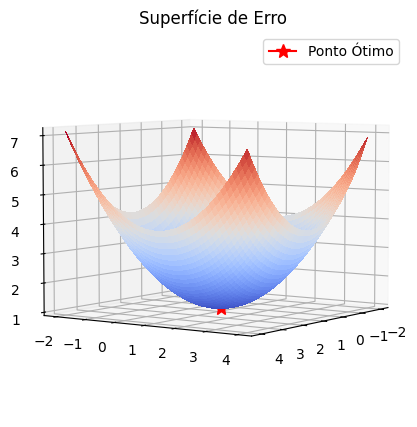

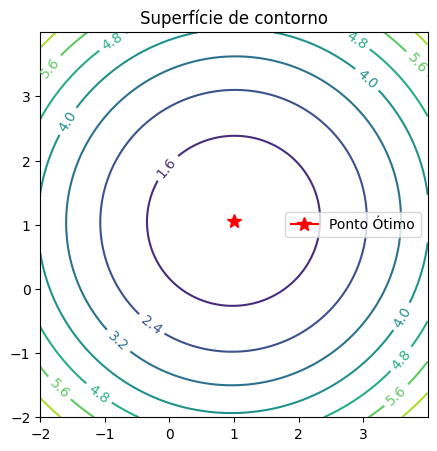

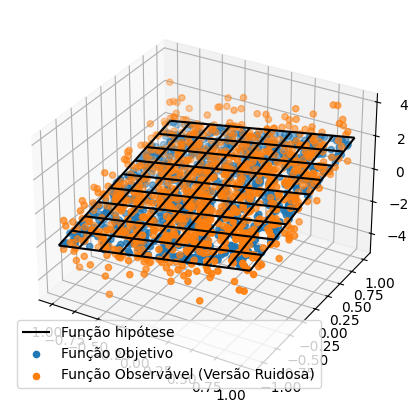

In [10]:
N = 1000 # Número de pontos de dados

# x1 e x2 são valores aleatórios uniformemente distribuídos entre -1 e 1.
x1 = 2*np.random.rand(N,1)-1
x2 = 2*np.random.rand(N,1)-1


# Criar o ruído (w) e calcular as saídas (y e y_noisy)
w = np.random.randn(N,1) # Ruído gaussiano (média 0, desvio padrão 1)

y = x1 + x2  # Função objetivo real (sem ruído) {função real que queremos aprender}
y_noisy = y + w # Função observável (com ruído) {o modelo vai tentar ajustar baseado nessa versão ruidosa}


# Calcular os coeficientes da regressão linear
# Resolve a equação normal para encontrar os coeficientes a0 e a1 da regressão: y = a1x1 +a2x2
# Retorna-> a_numpy_plano: coeficientes a1 e a2 aprendidos.
#           y_pred_plano: valores previstos pela equação.
#           Je_optimum_plano: erro quadrático médio da previsão.
a_numpy_plano, y_pred_plano, Je_optimum_plano = eq_normal_without_intercept_plano(x1, x2, y_noisy)



# Cria a superfície de erro
A1, A2, J = error_surface_3D(x1, x2, y_noisy, a_numpy_plano, Je_optimum_plano)

# Plota a superfície de erro, mostra o ponto ótimo onde o erro é mínimo.
error_surface_3D_plot(A1, A2, J, a_numpy_plano, Je_optimum_plano)

# Plota um gráfico de contorno (tipo um mapa de calor) mostrando a variação do erro.
error_surface_3D_contour(A1, A2, J, a_numpy_plano)

# Plotar os dados e a previsão da regressão
plot_objetivo_observavel_pred_3D (x1, x2, y, y_noisy, y_pred_plano, a_numpy_plano)

As funções que você está usando foram projetadas para um plano no espaço 3D, ou seja, para uma função linear do tipo:  $y = a_1 x_1 + a_2 x_2$


Isso significa que elas assumem que a relação entre x1, x2 e y é linear.

✅ Se a função for linear ( $y = a_1 x_1 + a_2 x_2$), o código funciona sem mudanças.

⚠️ Se a função for não linear, precisa modificar a matriz X e os cálculos da superfície de erro.



